In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from collections import Counter

Looking in indexes: https://download.pytorch.org/whl/cu118


In [2]:
BICYCLE_IDX = 8
MOTORCYCLE_IDX = 48
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DINO_MEAN = (0.485, 0.456, 0.406)
DINO_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 64
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
FEATURE_DIM = 384

print(f"Устройство: {DEVICE}")
print(f"CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomCrop(224, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(DINO_MEAN, DINO_STD)
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(DINO_MEAN, DINO_STD)
])

train_dataset_full = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_train)
test_dataset_full = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform_test)

print(f"Полный датасет: train={len(train_dataset_full)}, test={len(test_dataset_full)}")

Устройство: cuda
CUDA доступна: True
GPU: Tesla T4


100%|██████████| 169M/169M [00:04<00:00, 41.1MB/s]


Полный датасет: train=50000, test=10000


In [3]:
def filter_dataset(dataset, bicycle_idx, motorcycle_idx):
    indices = []
    new_targets = []
    for idx, target in enumerate(dataset.targets):
        if target == bicycle_idx:
            new_targets.append(0)
        elif target == motorcycle_idx:
            new_targets.append(1)
        else:
            new_targets.append(2)
        indices.append(idx)

    class CustomDataset(torch.utils.data.Dataset):
        def __init__(self, dataset, indices, new_targets):
            self.dataset = dataset
            self.indices = indices
            self.new_targets = new_targets
        def __getitem__(self, index):
            idx = self.indices[index]
            img, _ = self.dataset[idx]
            return img, self.new_targets[index]
        def __len__(self):
            return len(self.indices)

    return CustomDataset(dataset, indices, new_targets)

train_dataset = filter_dataset(train_dataset_full, BICYCLE_IDX, MOTORCYCLE_IDX)
test_dataset = filter_dataset(test_dataset_full, BICYCLE_IDX, MOTORCYCLE_IDX)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Размер train: {len(train_dataset)}, test: {len(test_dataset)}")
print(f"Распределение train: {dict(Counter([train_dataset[i][1] for i in range(len(train_dataset))]))}")

Размер train: 50000, test: 10000
Распределение train: {2: 49000, 0: 500, 1: 500}


In [4]:
print("Загрузка модели DINOv2...")
dinov2_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', pretrained=True)
dinov2_model.eval().to(DEVICE)

for param in dinov2_model.parameters():
    param.requires_grad = False

def extract_features(images):
    with torch.no_grad():
        output = dinov2_model.forward_features(images)
        return output['x_norm_clstoken']

print("Модель загружена и заморожена")

classifier = nn.Linear(FEATURE_DIM, 3).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("Классификатор готов")

Загрузка модели DINOv2...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 224MB/s]


Модель загружена и заморожена
Классификатор готов


In [12]:
def train_epoch(classifier, loader, criterion, optimizer, device):
    classifier.train()
    total_loss, correct, total = 0, 0, 0

    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        feats = extract_features(images)
        logits = classifier(feats)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = logits.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

        if (i + 1) % 50 == 0:
            current_acc = correct / total
            print(f"  Батч {i+1}/{len(loader)} | Loss: {loss.item():.4f} | Acc: {current_acc:.4f}")

    return total_loss / len(loader), correct / total

def test_epoch(classifier, loader, criterion, device):
    classifier.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            feats = extract_features(images)
            logits = classifier(feats)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            _, preds = logits.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels

In [13]:
import torch
print(f"CUDA доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Использование GPU: {next(dinov2_model.parameters()).device}")
else:
    print("GPU НЕ включён! Вы всё ещё на CPU!")

CUDA доступен: True
GPU: Tesla T4
Использование GPU: cuda:0


In [14]:
print("Начало обучения...")
train_accs, test_accs = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(classifier, train_loader, criterion, optimizer, DEVICE)
    test_loss, test_acc, _, _ = test_epoch(classifier, test_loader, criterion, DEVICE)
    scheduler.step()
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f"Эпоха {epoch+1}/{NUM_EPOCHS}: Train {train_acc:.4f} | Test {test_acc:.4f}")

print("Обучение завершено")

Начало обучения...
  Батч 50/782 | Loss: 0.0004 | Acc: 0.9988
  Батч 100/782 | Loss: 0.0056 | Acc: 0.9983
  Батч 150/782 | Loss: 0.0008 | Acc: 0.9983
  Батч 200/782 | Loss: 0.0003 | Acc: 0.9987
  Батч 250/782 | Loss: 0.0007 | Acc: 0.9988
  Батч 300/782 | Loss: 0.0005 | Acc: 0.9985
  Батч 350/782 | Loss: 0.0007 | Acc: 0.9986
  Батч 400/782 | Loss: 0.0002 | Acc: 0.9986
  Батч 450/782 | Loss: 0.0008 | Acc: 0.9986
  Батч 500/782 | Loss: 0.0004 | Acc: 0.9986
  Батч 550/782 | Loss: 0.0001 | Acc: 0.9986
  Батч 600/782 | Loss: 0.0006 | Acc: 0.9985
  Батч 650/782 | Loss: 0.0006 | Acc: 0.9985
  Батч 700/782 | Loss: 0.0002 | Acc: 0.9985
  Батч 750/782 | Loss: 0.0001 | Acc: 0.9986
Эпоха 1/15: Train 0.9986 | Test 0.9974
  Батч 50/782 | Loss: 0.0001 | Acc: 0.9984
  Батч 100/782 | Loss: 0.0020 | Acc: 0.9991
  Батч 150/782 | Loss: 0.0005 | Acc: 0.9990
  Батч 200/782 | Loss: 0.0001 | Acc: 0.9991
  Батч 250/782 | Loss: 0.0001 | Acc: 0.9993
  Батч 300/782 | Loss: 0.0005 | Acc: 0.9991
  Батч 350/782 | Los

Финальная точность: 99.78%


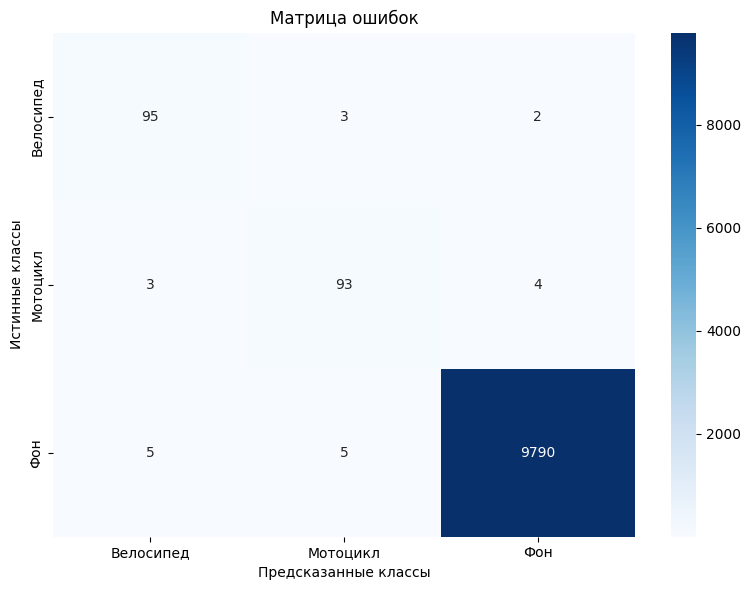

Отчёт по классификации:
              precision    recall  f1-score   support

   Велосипед       0.92      0.95      0.94       100
    Мотоцикл       0.92      0.93      0.93       100
         Фон       1.00      1.00      1.00      9800

    accuracy                           1.00     10000
   macro avg       0.95      0.96      0.95     10000
weighted avg       1.00      1.00      1.00     10000



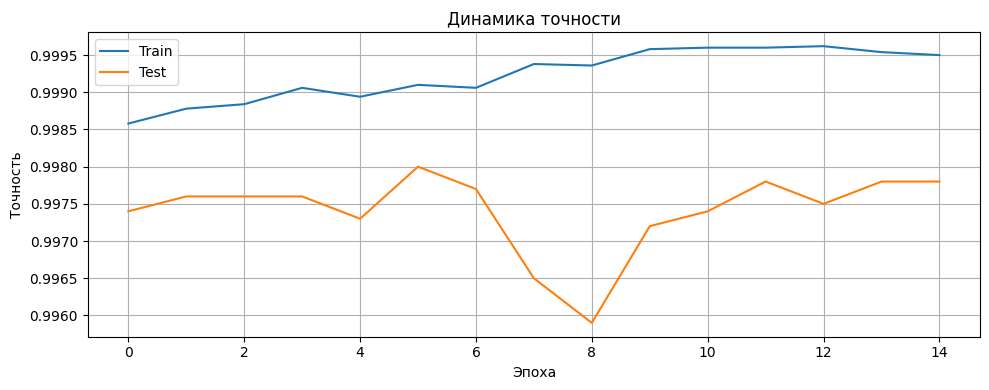

In [15]:
_, final_acc, all_preds, all_labels = test_epoch(classifier, test_loader, criterion, DEVICE)
print(f"Финальная точность: {final_acc*100:.2f}%")

class_names = ['Велосипед', 'Мотоцикл', 'Фон']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.tight_layout()
plt.show()

print("Отчёт по классификации:")
print(classification_report(all_labels, all_preds, target_names=class_names))

plt.figure(figsize=(10, 4))
plt.plot(train_accs, label='Train')
plt.plot(test_accs, label='Test')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('Динамика точности')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Тестирование на grayscale-изображениях (исправлено)...
Точность на grayscale: 97.79%
Разница с RGB: 1.99 п.п.

Отчёт по классификации (grayscale):
              precision    recall  f1-score   support

   Велосипед       1.00      0.09      0.17       100
    Мотоцикл       0.00      0.00      0.00       100
         Фон       0.98      1.00      0.99      9800

    accuracy                           0.98     10000
   macro avg       0.66      0.36      0.38     10000
weighted avg       0.97      0.98      0.97     10000



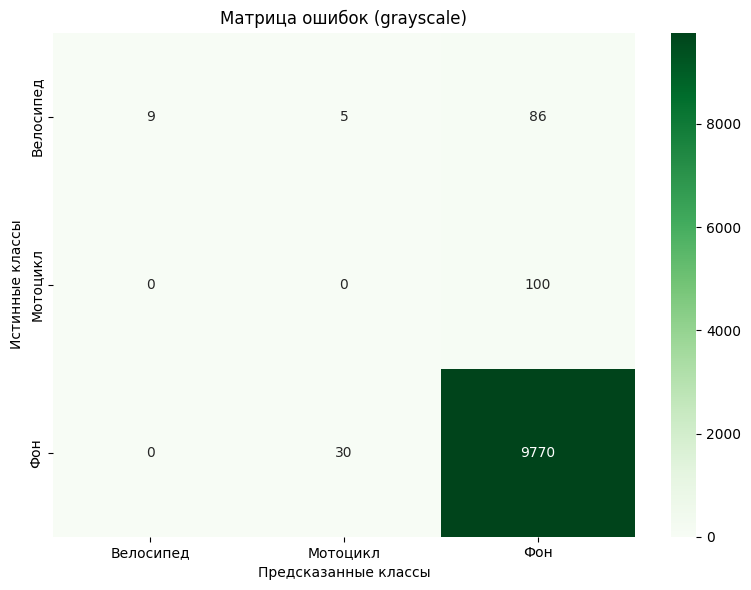

In [20]:
print("Тестирование на grayscale-изображениях (исправлено)...")

def test_grayscale_fixed(classifier, loader, device):
    classifier.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            # Grayscale: 1 канал
            images_gray = transforms.Grayscale(num_output_channels=1)(images)

            # Дублируем в 3 канала для DINOv2
            images_gray_3ch = images_gray.repeat(1, 3, 1, 1)

            # Переносим на устройство
            images_gray_3ch = images_gray_3ch.to(device)
            labels = labels.to(device)

            # Нормализация
            mean = torch.tensor(DINO_MEAN).view(1, 3, 1, 1).to(device)
            std = torch.tensor(DINO_STD).view(1, 3, 1, 1).to(device)
            images_norm = (images_gray_3ch - mean) / std

            # Экстракция фичей
            feats = extract_features(images_norm)
            logits = classifier(feats)
            _, preds = logits.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return correct / total, all_preds, all_labels

gray_acc, preds_gray, labels_gray = test_grayscale_fixed(classifier, test_loader, DEVICE)
print(f"Точность на grayscale: {gray_acc*100:.2f}%")
print(f"Разница с RGB: {(final_acc - gray_acc)*100:.2f} п.п.")

# Отчёт по классам для grayscale
print("\nОтчёт по классификации (grayscale):")
print(classification_report(labels_gray, preds_gray, target_names=class_names))

cm_gray = confusion_matrix(labels_gray, preds_gray)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gray, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок (grayscale)')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.tight_layout()
plt.show()